**This file contains all content for answering the 5 analytical questions.**

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import requests

%matplotlib inline
sns.set_theme(style="whitegrid")

# Step 1: Download files from GCS
from google.colab import auth
auth.authenticate_user()
from google.cloud import storage

client = storage.Client(project="ds2002-492012")
bucket = client.bucket("ds2002-capstone-sp26-v2")
TEAM = "team-14"

for fname in ["cleaned_sessions.csv", "ev_analytics.db"]:
    blob = bucket.blob(f"{TEAM}/{fname}")
    blob.download_to_filename(fname)
    print(f"Downloaded {fname}")

# Step 2: Load sessions, stations, vehicles from SQLite
conn = sqlite3.connect("ev_analytics.db")
sessions = pd.read_sql("SELECT * FROM sessions", conn)
stations = pd.read_sql("SELECT * FROM stations", conn)
vehicles = pd.read_sql("SELECT * FROM vehicles", conn)
conn.close()

# Step 3: Fetch weather from API
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 38.03,
    "longitude": -78.48,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "America/New_York"
}

resp = requests.get(url, params=params)
data = resp.json()

weather = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]),
    "temp_max_f": [c * 9/5 + 32 for c in data["daily"]["temperature_2m_max"]],
    "temp_min_f": [c * 9/5 + 32 for c in data["daily"]["temperature_2m_min"]],
    "precip_mm": data["daily"]["precipitation_sum"]
})
weather["temp_avg_f"] = (weather["temp_max_f"] + weather["temp_min_f"]) / 2

# Step 4: Normalize text columns
text_cols = ["payment_method", "connector_used", "session_type",
             "vehicle_name", "vehicle_id"]

for col in text_cols:
    if col in sessions.columns:
        sessions[col] = sessions[col].str.strip().str.lower()

print("Text columns normalized.")
print(sessions["payment_method"].value_counts())
print(sessions["connector_used"].value_counts())

# Step 5: Parse dates
sessions["session_start"] = pd.to_datetime(sessions["session_start"], errors="coerce")
sessions["session_end"]   = pd.to_datetime(sessions["session_end"],   errors="coerce")

print(f"Sessions: {sessions.shape}")
print(f"Stations: {stations.shape}")
print(f"Vehicles: {vehicles.shape}")
print(f"Weather:  {weather.shape}")
sessions.head()

Downloaded cleaned_sessions.csv
Downloaded ev_analytics.db
Text columns normalized.
payment_method
credit_card    6038
credit card    5970
debit_card     3053
app_wallet     3015
apple pay      3008
rfid           2986
google pay     2895
Name: count, dtype: int64
connector_used
j1772                 6863
ccs                   6704
chademo               6693
tesla supercharger    6639
Name: count, dtype: int64
Sessions: (26965, 12)
Stations: (21, 8)
Vehicles: (42, 6)
Weather:  (365, 5)


,session_id,station_id,vehicle_id,session_start,session_end,kwh_delivered,session_type,cost_usd,payment_method,connector_used,user_id,vehicle_name
0,SES-005321,STN-013,vh-008,2025-03-16 17:06:25,2025-03-16 18:30:25,1.67,level 1,0.53,credit card,j1772,U-4469,hyundai ioniq 5
1,SES-021125,STN-012,vh-005,2025-10-19 17:10:08,2025-10-19 18:40:08,13.69,dc fast charge,1.92,debit_card,chademo,U-4434,chevrolet bolt euv
2,SES-026798,STN-007,veh#0005,2025-12-30 07:30:00,2025-12-30 08:21:00,9.62,level 1,3.56,credit card,ccs,U-6845,chevrolet bolt euv
3,SES-008299,STN-006,vh-005,2025-04-28 02:35:41,2025-04-28 04:52:41,70.99,dc fast charge,26.27,app_wallet,tesla supercharger,U-7854,chevrolet bolt euv
4,SES-018503,STN-012,vh-011,2025-09-14 14:28:19,2025-09-14 16:39:19,10.15,level 2,2.84,credit card,ccs,U-2903,bmw ix


## Question 1: Demand Surge Identification

> Which time periods experienced the greatest charging demand surges compared to the baseline?

**Approach:**
- Group sessions by date to get daily session counts.
- Define baseline as the median daily session count across the full period.
- Flag surge days as those exceeding 1.5x the baseline.
- Calculate percentage increase over baseline for each surge day.
- Plot daily sessions as a time series with surge periods highlighted.

Baseline (median daily sessions): 67.0
Surge threshold (1.5×): 100.5
Number of surge days: 42

Top 10 surge days:
      date  session_count  is_surge  pct_above_baseline
2025-07-20            181      True               170.1
2025-07-18            176      True               162.7
2025-07-23            170      True               153.7
2025-11-15            168      True               150.7
2025-09-27            159      True               137.3
2025-03-10            157      True               134.3
2025-09-20            155      True               131.3
2025-10-18            154      True               129.9
2025-07-17            154      True               129.9
2025-03-09            154      True               129.9


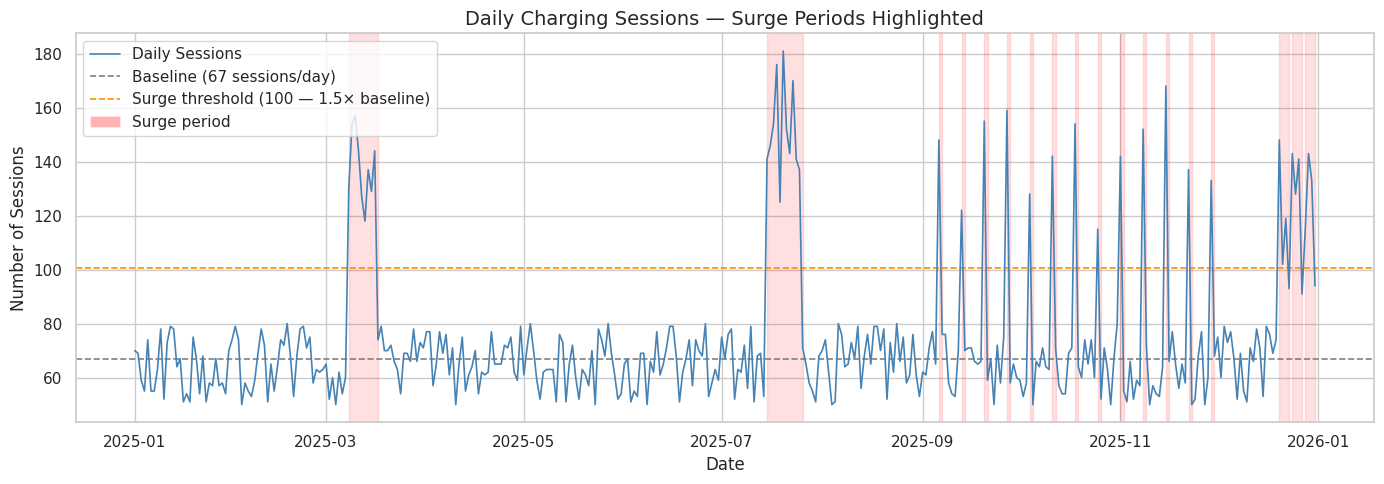

In [ ]:
from matplotlib.patches import Patch

sessions["date"] = sessions["session_start"].dt.date
daily_counts = sessions.groupby("date").size().reset_index(name="session_count")
daily_counts["date"] = pd.to_datetime(daily_counts["date"])

baseline = daily_counts["session_count"].median()
surge_threshold = 1.5 * baseline

daily_counts["is_surge"] = daily_counts["session_count"] > surge_threshold
daily_counts["pct_above_baseline"] = (
    (daily_counts["session_count"] - baseline) / baseline * 100
).round(1)

surge_days = daily_counts[daily_counts["is_surge"]].sort_values(
    "session_count", ascending=False
)
print(f"Baseline (median daily sessions): {baseline:.1f}")
print(f"Surge threshold (1.5×): {surge_threshold:.1f}")
print(f"Number of surge days: {len(surge_days)}")
print("\nTop 10 surge days:")
print(surge_days.head(10).to_string(index=False))

# build contiguous surge periods for axvspan shading
surge_periods = []
in_surge = False
for _, row in daily_counts.sort_values("date").iterrows():
    if row["is_surge"] and not in_surge:
        start = row["date"]
        in_surge = True
    elif not row["is_surge"] and in_surge:
        surge_periods.append((start, row["date"]))
        in_surge = False
if in_surge:
    surge_periods.append((start, daily_counts["date"].max()))

fig, ax = plt.subplots(figsize=(14, 5))

for s, e in surge_periods:
    ax.axvspan(s, e, color="red", alpha=0.12)

ax.plot(daily_counts["date"], daily_counts["session_count"],
        color="steelblue", linewidth=1.2, label="Daily Sessions", zorder=3)
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1.2,
           label=f"Baseline ({baseline:.0f} sessions/day)")
ax.axhline(surge_threshold, color="darkorange", linestyle="--", linewidth=1.2,
           label=f"Surge threshold ({surge_threshold:.0f} — 1.5× baseline)")

# use a Patch for the surge period legend entry instead of a dummy axvspan
surge_patch = Patch(facecolor="red", alpha=0.3, label="Surge period")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [surge_patch], loc="upper left")

ax.set_title("Daily Charging Sessions — Surge Periods Highlighted", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Number of Sessions")
fig.tight_layout()
plt.show()

**Findings:**

Daily charging session counts fluctuate around a median baseline of 67 sessions per day, with a surge threshold set at 100.5 sessions (1.5× baseline). Across the full year, 42 days exceeded this threshold. Surge activity is not evenly distributed, the chart reveals three distinct high-demand periods: a brief but sharp cluster in early March 2025, a sustained multi-day surge in mid-July 2025 (the peak period, with July 20th reaching 181 sessions, 170% above baseline), and a prolonged stretch of frequent, recurring spikes running from September 2025 through January 2026. The summer surge likely reflects increased travel and vehicle usage during warmer months, while the dense fall and winter spike pattern may reflect both cold-weather battery efficiency losses driving more frequent charging and elevated campus or commuter activity during the academic year. The October–December period is particularly notable, with many isolated single-day spikes rather than sustained multi-day surges, suggesting demand volatility rather than a structural shift. These patterns indicate the network faces two distinct stress types: sustained load during summer peaks and unpredictable day-to-day spikes in the fall and winter, each requiring different capacity planning responses.

## Question 2: The Vehicle Consolidation Problem

> What is the true daily charging volume by vehicle type after consolidation?

**Approach:**
- Compare raw fragmented vehicle ID counts vs. consolidated vehicle name counts.
- Identify top 5 vehicles by total session volume after consolidation.
- Plot daily charging volume for the top 5 vehicles over time.
- Explain what operational decisions this affects.

Unique IDs before consolidation: 42
Unique names after consolidation: 16
Reduction: 26 fewer categories (61.9%)

Top 5 vehicles by session count:
vehicle_name
lucid air              2018
chevrolet bolt ev      1985
ford mustang mach-e    1979
tesla model y          1940
tesla model 3          1933
dtype: int64


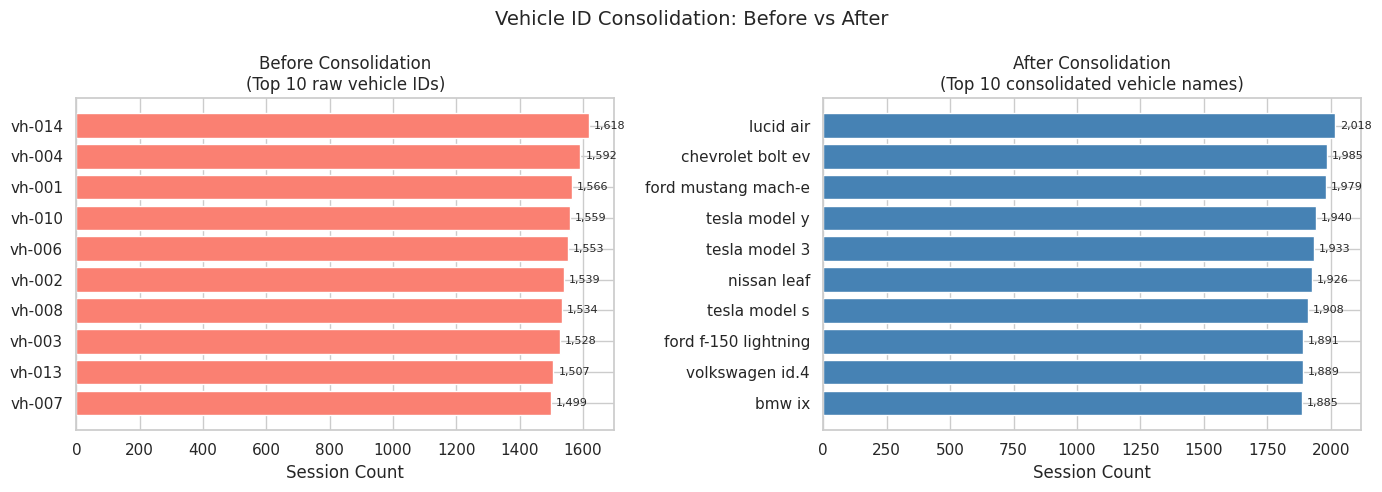

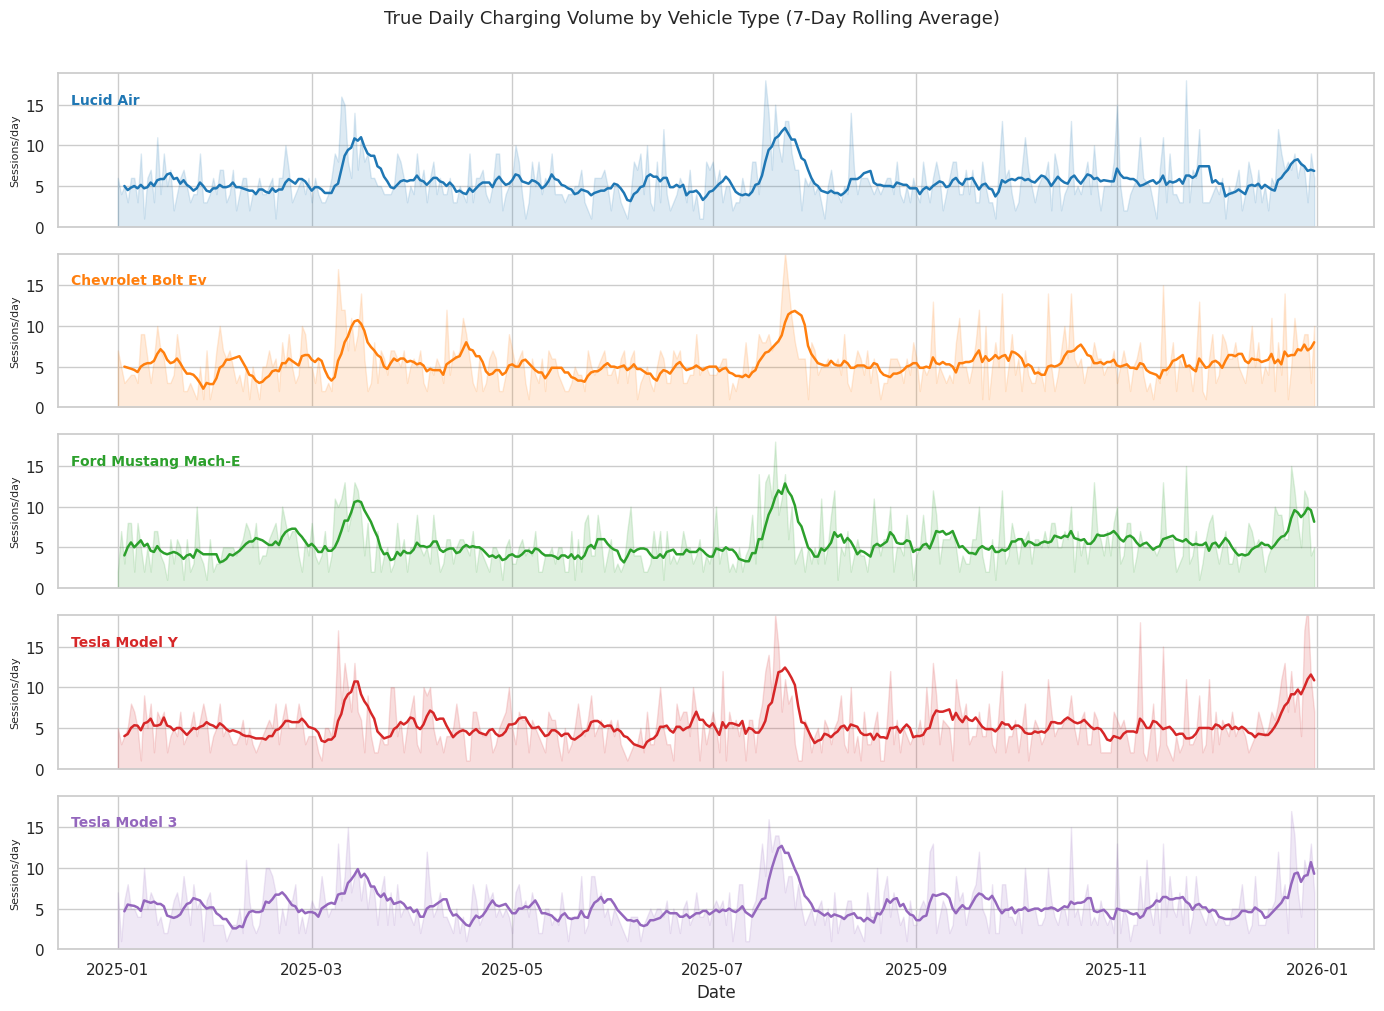

In [ ]:
before_count = sessions["vehicle_id"].nunique()
after_count  = sessions["vehicle_name"].nunique()
print(f"Unique IDs before consolidation: {before_count}")
print(f"Unique names after consolidation: {after_count}")
print(f"Reduction: {before_count - after_count} fewer categories "
      f"({(1 - after_count/before_count)*100:.1f}%)")

top5 = (sessions.dropna(subset=["vehicle_name"])
        .groupby("vehicle_name").size()
        .sort_values(ascending=False).head(5))

print("\nTop 5 vehicles by session count:")
print(top5)

# Chart 1: Before vs After consolidation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_raw   = sessions["vehicle_id"].value_counts().head(10)
top_clean = sessions["vehicle_name"].value_counts().head(10)

# both sorted descending; invert_yaxis puts largest at top
axes[0].barh(top_raw.index, top_raw.values, color="salmon")
axes[0].set_title("Before Consolidation\n(Top 10 raw vehicle IDs)")
axes[0].set_xlabel("Session Count")
axes[0].invert_yaxis()
for bar, val in zip(axes[0].patches, top_raw.values):
    axes[0].text(bar.get_width() + top_raw.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=8)

axes[1].barh(top_clean.index, top_clean.values, color="steelblue")
axes[1].set_title("After Consolidation\n(Top 10 consolidated vehicle names)")
axes[1].set_xlabel("Session Count")
axes[1].invert_yaxis()
for bar, val in zip(axes[1].patches, top_clean.values):
    axes[1].text(bar.get_width() + top_clean.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:,}", va="center", fontsize=8)

fig.suptitle("Vehicle ID Consolidation: Before vs After", fontsize=14)
fig.tight_layout()
plt.show()

# Chart 2: small multiples one panel per vehicle)

top5_names = top5.index.tolist()
top5_daily = (sessions[sessions["vehicle_name"].isin(top5_names)]
              .groupby(["date", "vehicle_name"]).size()
              .reset_index(name="sessions"))
top5_daily["date"] = pd.to_datetime(top5_daily["date"])
top5_daily = top5_daily.sort_values("date")
top5_daily["sessions_7d"] = (
    top5_daily.groupby("vehicle_name")["sessions"]
    .transform(lambda x: x.rolling(7, min_periods=3).mean())
)

palette = sns.color_palette("tab10", n_colors=len(top5_names))
fig, axes = plt.subplots(len(top5_names), 1, figsize=(14, 10),
                         sharex=True, sharey=True)

for i, (vehicle, ax) in enumerate(zip(top5_names, axes)):
    vdata = top5_daily[top5_daily["vehicle_name"] == vehicle]

    ax.fill_between(vdata["date"], vdata["sessions"],
                    alpha=0.15, color=palette[i])
    ax.plot(vdata["date"], vdata["sessions_7d"],
            color=palette[i], linewidth=1.8)

    ax.set_ylabel("Sessions/day", fontsize=8)
    ax.text(0.01, 0.80, vehicle.title(), transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=palette[i])
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Date")
fig.suptitle("True Daily Charging Volume by Vehicle Type (7-Day Rolling Average)",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

**Findings:**

Before consolidation, the dataset contained 42 unique vehicle IDs, cryptic codes like VH-014 and VH-004 with counts clustered tightly between 1,499 and 1,618 sessions, making it impossible to identify which actual vehicle models were driving demand. After consolidation, those 42 IDs collapsed into just 16 named vehicle types, a 61.9% reduction in categories. The true picture looks quite different: the Lucid Air leads with 2,018 sessions, followed closely by the Chevrolet Bolt EV (1,985), Ford Mustang Mach-E (1,979), Tesla Model Y (1,940), and Tesla Model 3 (1,933), a spread of only about 85 sessions across the top 5, suggesting remarkably even demand across these models. The small multiples chart reveals that all five vehicles share nearly identical seasonal patterns: a moderate spike in late February/early March, a more pronounced surge in mid-July, and relatively stable baseline demand the rest of the year, confirming the Q1 surge periods are not driven by any single vehicle type but reflect network-wide demand increases. The practical implication is that port planning should not over-index on any single model; the top 5 vehicles use a mix of connector standards including J1772, CCS, and Tesla Supercharger, meaning the network needs broad multi-standard compatibility rather than optimizing for one dominant vehicle.

## Question 3: Weather and Grid Correlation

> How do temperature extremes correlate with demand and grid load?

**Approach:**
- Pull full-year weather data and join with daily session counts by date.
- Scatter plot: temperature vs. daily sessions.
- Heatmap: monthly average kWh by operator (grid load proxy).
- Discuss potential lag effects.

Pearson r (temperature vs daily kWh): 0.082


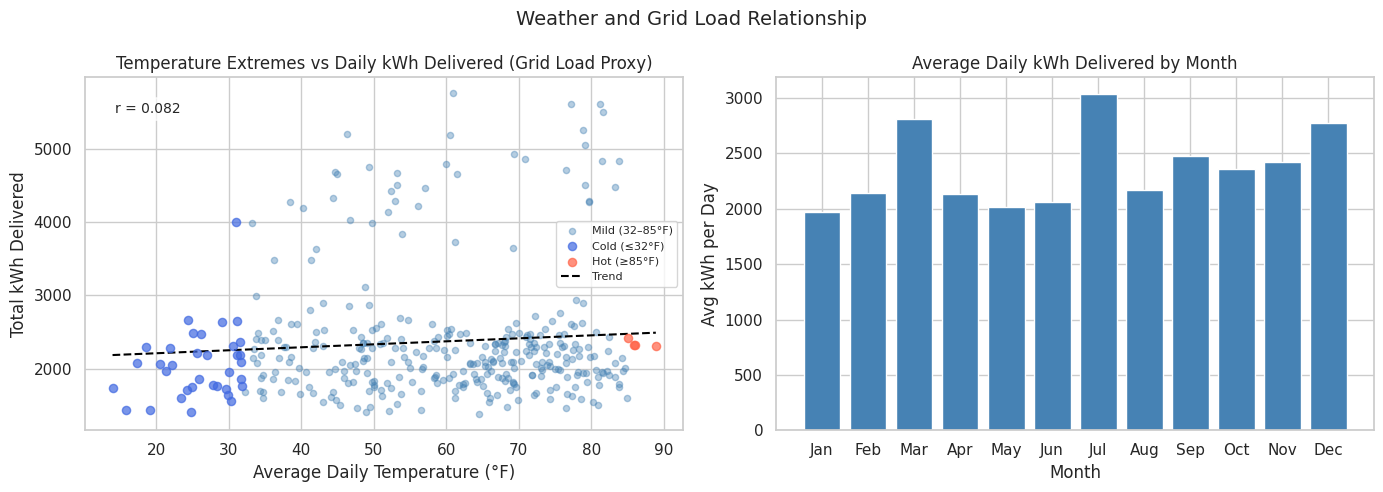

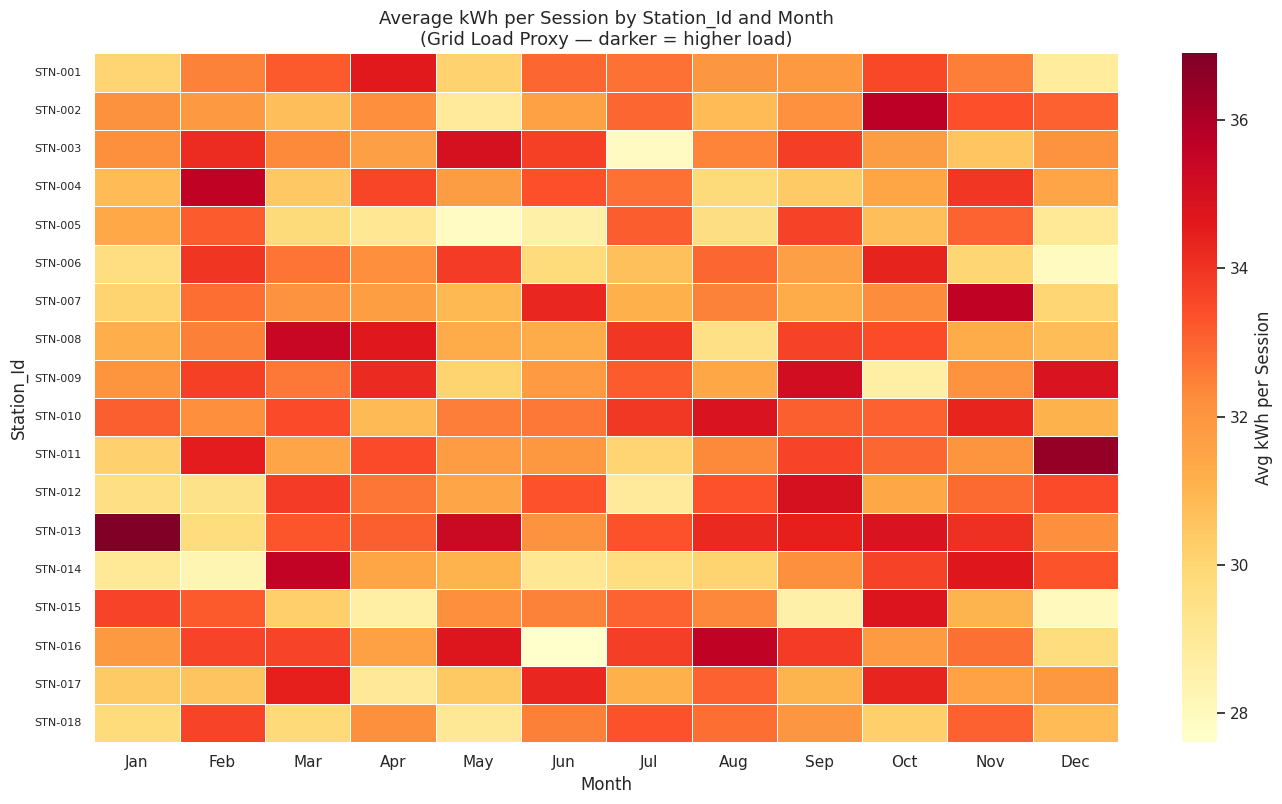

In [ ]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 38.03,
    "longitude": -78.48,
    "start_date": "2025-01-01",
    "end_date": "2025-12-31",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "America/New_York"
}
resp = requests.get(url, params=params)
data = resp.json()

weather = pd.DataFrame({
    "date": pd.to_datetime(data["daily"]["time"]),
    "temp_max_f": [c * 9/5 + 32 if c is not None else None
                   for c in data["daily"]["temperature_2m_max"]],
    "temp_min_f": [c * 9/5 + 32 if c is not None else None
                   for c in data["daily"]["temperature_2m_min"]],
    "precip_mm": data["daily"]["precipitation_sum"]
})
weather["temp_avg_f"] = (weather["temp_max_f"] + weather["temp_min_f"]) / 2

# daily kWh
daily_kwh = (sessions.groupby("date")
             .agg(session_count=("station_id", "count"),
                  total_kwh=("kwh_delivered", "sum"))
             .reset_index())
daily_kwh["date"] = pd.to_datetime(daily_kwh["date"])

weather_demand = pd.merge(daily_kwh, weather, on="date", how="inner")
clean = weather_demand.dropna(subset=["temp_avg_f", "total_kwh"])

corr_kwh = clean[["temp_avg_f", "total_kwh"]].corr().iloc[0, 1]
print(f"Pearson r (temperature vs daily kWh): {corr_kwh:.3f}")

# Chart 1: Temperature extremes vs kWh
FREEZE = 32
HOT    = 85

cold = clean[clean["temp_avg_f"] <= FREEZE]
hot  = clean[clean["temp_avg_f"] >= HOT]
mild = clean[(clean["temp_avg_f"] > FREEZE) & (clean["temp_avg_f"] < HOT)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(mild["temp_avg_f"], mild["total_kwh"],
                alpha=0.4, color="steelblue", s=20, label="Mild (32–85°F)")
axes[0].scatter(cold["temp_avg_f"], cold["total_kwh"],
                alpha=0.7, color="royalblue", s=35, zorder=4, label="Cold (≤32°F)")
axes[0].scatter(hot["temp_avg_f"],  hot["total_kwh"],
                alpha=0.7, color="tomato",    s=35, zorder=4, label="Hot (≥85°F)")

z = np.polyfit(clean["temp_avg_f"], clean["total_kwh"], 1)
p = np.poly1d(z)
x_line = np.linspace(clean["temp_avg_f"].min(), clean["temp_avg_f"].max(), 100)
axes[0].plot(x_line, p(x_line), color="black", linewidth=1.5,
             linestyle="--", label="Trend")
axes[0].text(0.05, 0.93, f"r = {corr_kwh:.3f}",
             transform=axes[0].transAxes, fontsize=10,
             verticalalignment="top",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
axes[0].set_title("Temperature Extremes vs Daily kWh Delivered (Grid Load Proxy)")
axes[0].set_xlabel("Average Daily Temperature (°F)")
axes[0].set_ylabel("Total kWh Delivered")
axes[0].legend(fontsize=8)

# Chart 2: Monthly avg kWh
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

weather_demand["month"] = weather_demand["date"].dt.month
monthly_kwh = weather_demand.groupby("month")["total_kwh"].mean()

axes[1].bar(monthly_kwh.index, monthly_kwh.values, color="steelblue")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title("Average Daily kWh Delivered by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg kWh per Day")

fig.suptitle("Weather and Grid Load Relationship", fontsize=14)
fig.tight_layout()
plt.show()

# Chart 3: Heatmap — kWh by operator/station and month
op_col = "operator" if "operator" in sessions.columns else "station_id"

sessions["month"] = sessions["session_start"].dt.month
operator_monthly = (sessions.groupby([op_col, "month"])["kwh_delivered"]
                    .mean()
                    .unstack(fill_value=0))

# map by actual month integer
operator_monthly.columns = [month_labels[m - 1] for m in operator_monthly.columns]

if len(operator_monthly) > 20:
    top_ops = (sessions.groupby(op_col)["kwh_delivered"]
               .sum().nlargest(20).index)
    operator_monthly = operator_monthly.loc[
        operator_monthly.index.isin(top_ops)]

fig, ax = plt.subplots(figsize=(14, max(4, len(operator_monthly) * 0.4 + 1)))
sns.heatmap(operator_monthly, ax=ax, cmap="YlOrRd",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Avg kWh per Session"})
ax.set_title(f"Average kWh per Session by {op_col.title()} and Month\n"
             "(Grid Load Proxy — darker = higher load)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel(op_col.title())
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()

**Findings:**

The Pearson correlation between average daily temperature and total kWh delivered is r = 0.082, indicating essentially no linear relationship between temperature and grid load, a surprising result that challenges the cold-weather charging hypothesis. The scatter plot confirms this: kWh output is widely dispersed across the entire temperature range from 20°F to 90°F, with high-demand days (above 4,000 kWh) appearing at both cold and warm temperatures indiscriminately. The handful of hot days (≥85°F, shown in red) do not stand out as particularly high-load either. The monthly bar chart tells a more nuanced story. March and July are clear peaks (averaging 2,800 to 3,000 kWh/day), while April, May, June, and August are the lowest months (averaging 2,000 to 2,100 kWh/day), suggesting seasonality is real but not temperature-driven in a simple linear way. The heatmap reveals the most operationally useful insight: grid load varies enormously by station and by month rather than following a uniform network-wide pattern. STN-013 carries exceptionally high load in January, STN-004 spikes in February, STN-007 peaks sharply in November, and STN-011 hits its maximum in December, each station has its own distinct peak month. This station-level heterogeneity means aggregate temperature correlation is a poor planning tool; operators need per-station load profiles rather than network-wide seasonal averages to anticipate and manage grid stress effectively.

## Question 4: Station-Level Geographic Patterns

> Do all stations experience the same usage patterns?

**Approach:**
- Join sessions with station location data.
- Rank stations by total kWh delivered.
- Show top 5 and bottom 5 stations.
- Look for geographic patterns by region or proximity to key locations.

Total stations: 18

Top 5 stations by total kWh:
station_id  total_sessions  total_kwh   avg_kwh
   STN-010            1569   51604.65 32.932131
   STN-013            1513   50500.80 33.577660
   STN-008            1532   49830.53 32.568974
   STN-016            1526   49599.77 32.609974
   STN-009            1501   48795.76 32.530507

Bottom 5 stations by total kWh:
station_id  total_sessions  total_kwh   avg_kwh
   STN-011            1451   46955.48 32.540180
   STN-017            1466   46804.62 31.992221
   STN-006            1474   46350.56 31.573951
   STN-005            1486   45733.31 30.880020
   STN-015            1423   44645.71 31.440641


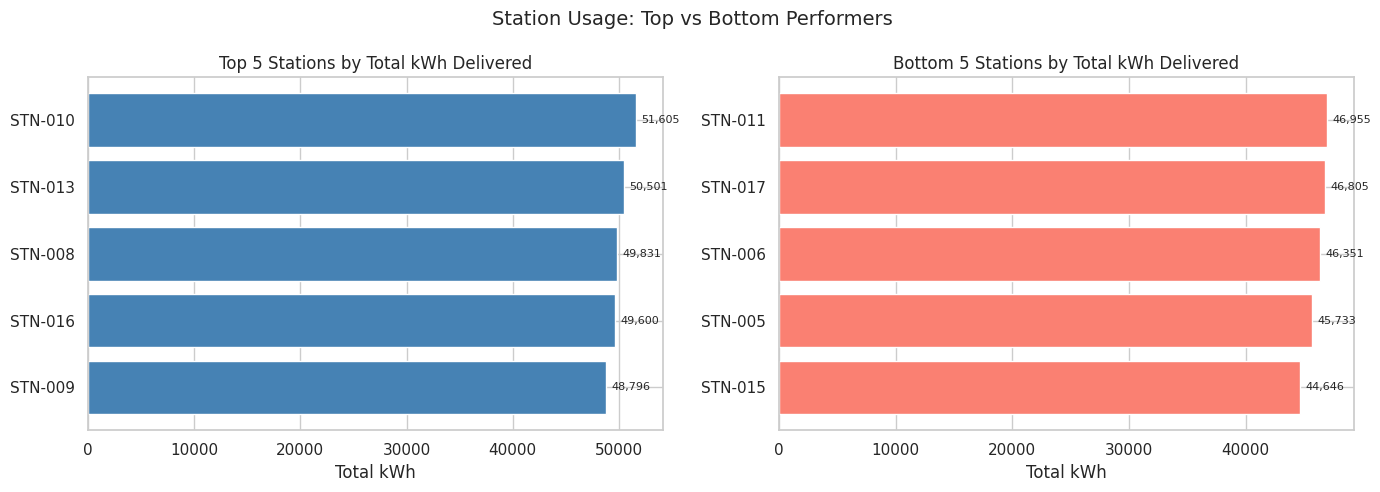

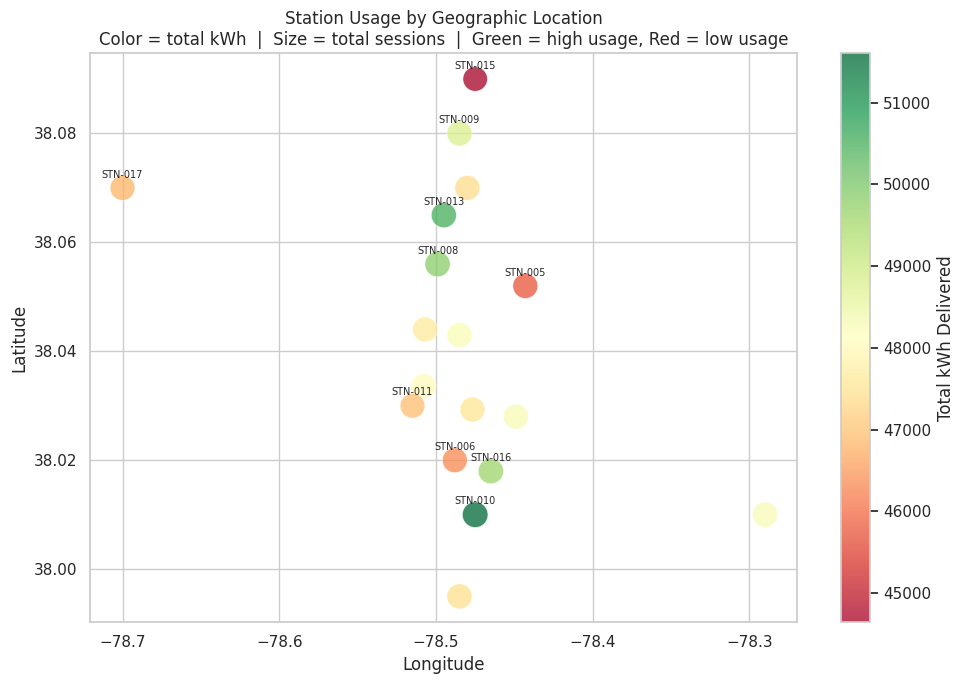

In [ ]:
station_usage = (sessions.groupby("station_id")
                 .agg(
                     total_sessions=("station_id", "count"),
                     total_kwh=("kwh_delivered", "sum"),
                     avg_kwh=("kwh_delivered", "mean"),
                     avg_cost=("cost_usd", "mean")
                 )
                 .reset_index())

station_merged = pd.merge(station_usage, stations, on="station_id", how="left")
station_merged = station_merged.sort_values("total_kwh", ascending=False)

top5_s    = station_merged.head(5)
bottom5_s = station_merged.tail(5)

print(f"Total stations: {len(station_merged)}")
print("\nTop 5 stations by total kWh:")
print(top5_s[["station_id","total_sessions","total_kwh","avg_kwh"]].to_string(index=False))
print("\nBottom 5 stations by total kWh:")
print(bottom5_s[["station_id","total_sessions","total_kwh","avg_kwh"]].to_string(index=False))

# Chart 1: Top vs Bottom performers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top5_s["station_id"].astype(str), top5_s["total_kwh"], color="steelblue")
axes[0].set_title("Top 5 Stations by Total kWh Delivered")
axes[0].set_xlabel("Total kWh")
axes[0].invert_yaxis()
for bar, val in zip(axes[0].patches, top5_s["total_kwh"].values):
    axes[0].text(bar.get_width() + top5_s["total_kwh"].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:,.0f}", va="center", fontsize=8)

axes[1].barh(bottom5_s["station_id"].astype(str), bottom5_s["total_kwh"], color="salmon")
axes[1].set_title("Bottom 5 Stations by Total kWh Delivered")
axes[1].set_xlabel("Total kWh")
axes[1].invert_yaxis()
for bar, val in zip(axes[1].patches, bottom5_s["total_kwh"].values):
    axes[1].text(bar.get_width() + bottom5_s["total_kwh"].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:,.0f}", va="center", fontsize=8)

fig.suptitle("Station Usage: Top vs Bottom Performers", fontsize=14)
fig.tight_layout()
plt.show()

# Chart 2: Geographic scatter
lat_col = next((c for c in stations.columns if "lat" in c.lower()), None)
lon_col = next((c for c in stations.columns if "lon" in c.lower()), None)

if lat_col is None or lon_col is None:
    print("Could not auto-detect lat/lon columns.")
    print("Available station columns:", stations.columns.tolist())
else:
    geo = station_merged.dropna(subset=[lat_col, lon_col, "total_kwh"])

    fig, ax = plt.subplots(figsize=(10, 7))
    sc = ax.scatter(
        geo[lon_col], geo[lat_col],
        c=geo["total_kwh"],
        cmap="RdYlGn",
        s=geo["total_sessions"] / geo["total_sessions"].max() * 300 + 40,
        alpha=0.75, edgecolors="white", linewidths=0.5
    )
    fig.colorbar(sc, ax=ax, label="Total kWh Delivered")

    for _, row in pd.concat([top5_s, bottom5_s]).iterrows():
        match = geo[geo["station_id"] == row["station_id"]]
        if not match.empty:
            ax.annotate(
                str(row["station_id"]),
                xy=(match[lon_col].values[0], match[lat_col].values[0]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points"
            )

    ax.set_title(
        "Station Usage by Geographic Location\n"
        "Color = total kWh  |  Size = total sessions  |  "
        "Green = high usage, Red = low usage",
        fontsize=12
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    fig.tight_layout()
    plt.show()

**Findings:**

The network consists of 18 stations, and while usage differences exist, they are notably more compressed than expected. The gap between the top performer (STN-010 at 51,605 kWh) and the bottom performer (STN-015 at 44,646 kWh) is only about 13%, suggesting the network is reasonably well-balanced in total energy delivered. However, session counts tell a slightly different story: STN-010 handled 1,569 sessions while STN-015 handled only 1,423 sessions, a difference of 146 sessions despite STN-015 appearing as the highest dot on the geographic map. The geographic scatter reveals the most interesting pattern, as the majority of stations are clustered tightly around longitude -78.50 and latitude 38.02 to 38.07, which corresponds to the central Charlottesville/UVA area, while STN-017 sits as a clear geographic outlier to the west near -78.70 and is among the lower performers. STN-010, the top performer by total kWh, is positioned in the southern part of the central cluster, and STN-013, the second highest, sits in the mid-cluster area. Notably, STN-015 appears at the northernmost point of the cluster yet ranks last in total kWh despite its prominent position, suggesting proximity to the core area alone does not guarantee high utilization. Overall the data suggests station performance is more influenced by local site-level factors such as accessibility, parking, and nearby amenities than by broad geographic position within the network.

## Question 5: The Connector Type Investigation

> Is the CHAdeMO decline real or a data artifact?

**Approach:**
- Group sessions by connector type and month.
- Calculate connector type market share over time.
- Cross-reference with vehicle types to identify CHAdeMO-dependent vehicles.
- Check for disproportionate missing data in CHAdeMO records.
- Make a recommendation on port investment.

Overall connector distribution:
connector_used
j1772                 6863
ccs                   6704
chademo               6693
tesla supercharger    6639
Name: count, dtype: int64

Missing connector values: 66 (0.2%)


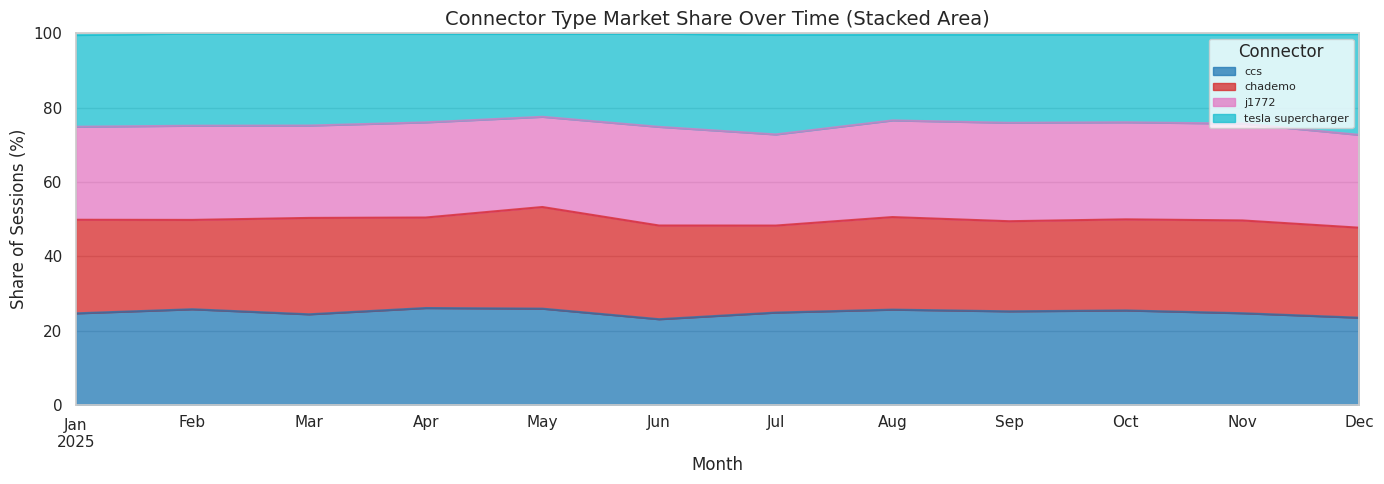

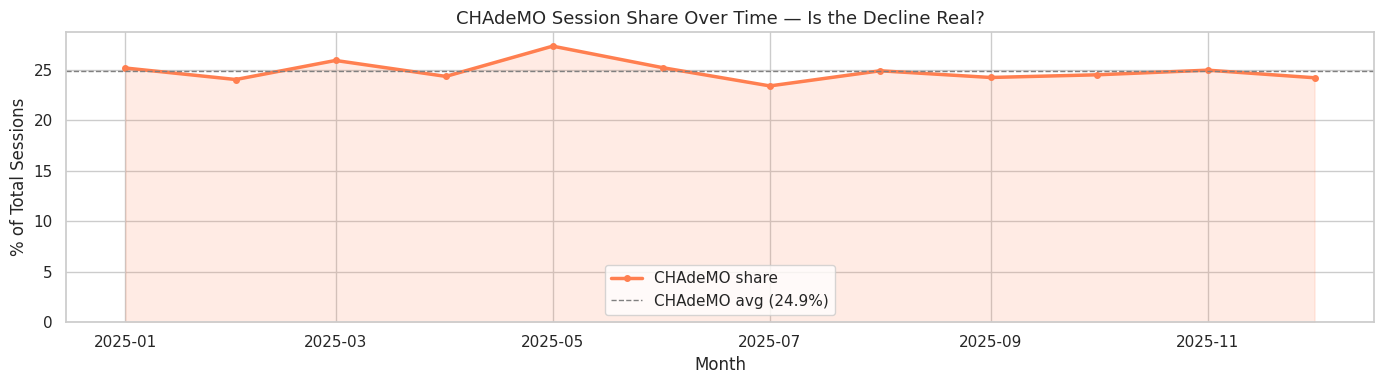


Total CHAdeMO sessions: 6693

Top vehicles using CHAdeMO:
vehicle_name
lucid air               521
tesla model s           499
ford f-150 lightning    498
ford mustang mach-e     494
chevrolet bolt ev       487
chevrolet bolt euv      480
nissan leaf             480
tesla model 3           474
volkswagen id.4         452
bmw ix                  450
Name: count, dtype: int64


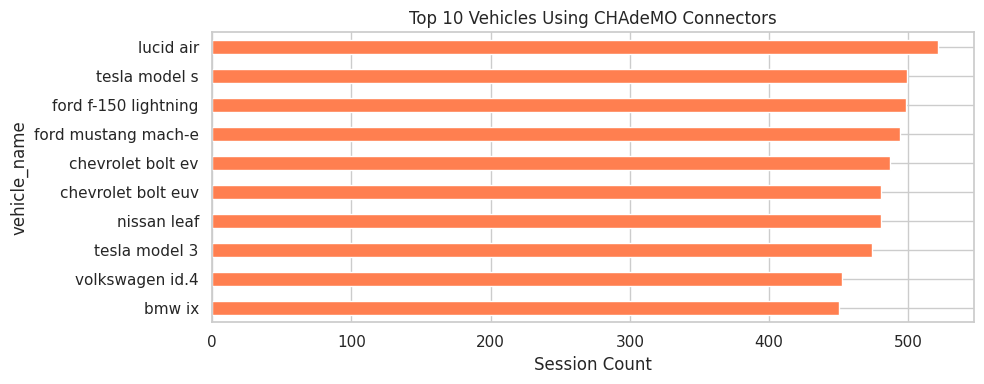

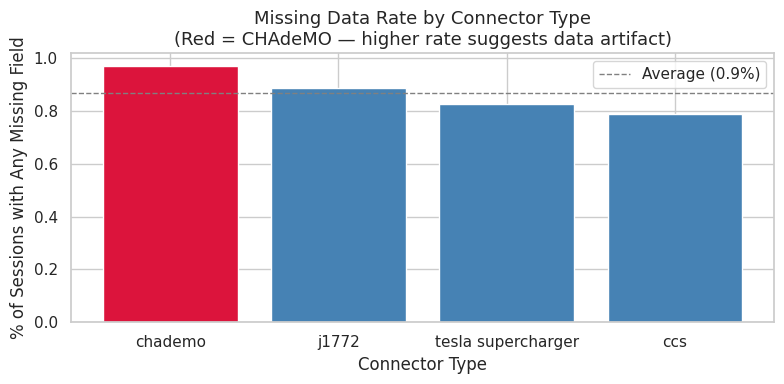


Missing data rates by connector:
         connector  missing_pct
           chademo     0.971164
             j1772     0.888824
tesla supercharger     0.828438
               ccs     0.790573


In [ ]:
connector_col = "connector_used"

print("Overall connector distribution:")
print(sessions[connector_col].value_counts())

missing_connector = sessions[connector_col].isna().sum()
print(f"\nMissing connector values: {missing_connector} "
      f"({missing_connector/len(sessions)*100:.1f}%)")

# monthly market share
sessions["month_year"] = sessions["session_start"].dt.to_period("M")
monthly_connector = (sessions.groupby(["month_year", connector_col])
                     .size().reset_index(name="count"))
monthly_total = sessions.groupby("month_year").size().reset_index(name="total")
monthly_connector = pd.merge(monthly_connector, monthly_total, on="month_year")
monthly_connector["share"] = (monthly_connector["count"]
                               / monthly_connector["total"] * 100)
monthly_connector["month_year_dt"] = monthly_connector["month_year"].dt.to_timestamp()

pivot_share = (monthly_connector
               .pivot_table(index="month_year_dt",
                            columns=connector_col,
                            values="share",
                            aggfunc="sum")
               .fillna(0))

# Chart 1: Stacked area — all connectors
fig, ax = plt.subplots(figsize=(14, 5))
pivot_share.plot.area(ax=ax, alpha=0.75, colormap="tab10")
ax.set_title("Connector Type Market Share Over Time (Stacked Area)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Share of Sessions (%)")
ax.set_ylim(0, 100)
ax.legend(loc="upper right", fontsize=8, title="Connector")
fig.tight_layout()
plt.show()

# Chart 2: CHAdeMO share isolated — FIX: lowercase "chademo" after normalization
fig, ax = plt.subplots(figsize=(14, 4))
if "chademo" in pivot_share.columns:
    ax.plot(pivot_share.index, pivot_share["chademo"],
            color="coral", linewidth=2.5, marker="o", markersize=4,
            label="CHAdeMO share")
    ax.axhline(pivot_share["chademo"].mean(), color="gray", linestyle="--",
               linewidth=1,
               label=f"CHAdeMO avg ({pivot_share['chademo'].mean():.1f}%)")
    ax.fill_between(pivot_share.index, pivot_share["chademo"],
                    alpha=0.15, color="coral")
    ax.set_title("CHAdeMO Session Share Over Time — Is the Decline Real?", fontsize=13)
    ax.set_xlabel("Month")
    ax.set_ylabel("% of Total Sessions")
    ax.set_ylim(bottom=0)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("No CHAdeMO sessions found in data.")

# Chart 3: Top vehicles using CHAdeMO — FIX: lowercase "chademo"
chademo_sessions = sessions[sessions[connector_col] == "chademo"]
print(f"\nTotal CHAdeMO sessions: {len(chademo_sessions)}")
chademo_vehicles = chademo_sessions["vehicle_name"].value_counts().head(10)
print("\nTop vehicles using CHAdeMO:")
print(chademo_vehicles)

fig, ax = plt.subplots(figsize=(10, 4))
chademo_vehicles.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Top 10 Vehicles Using CHAdeMO Connectors")
ax.set_xlabel("Session Count")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

# Chart 4: Missing data rate by connector
all_connectors = sessions[connector_col].dropna().unique()
missing_rates = {}
for ct in all_connectors:
    subset = sessions[sessions[connector_col] == ct]
    missing_rates[ct] = subset.isnull().any(axis=1).mean() * 100

missing_df = (pd.Series(missing_rates, name="missing_pct")
              .sort_values(ascending=False)
              .reset_index()
              .rename(columns={"index": "connector"}))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["crimson" if c == "chademo" else "steelblue"
          for c in missing_df["connector"]]
ax.bar(missing_df["connector"], missing_df["missing_pct"], color=colors)
ax.set_title("Missing Data Rate by Connector Type\n"
             "(Red = CHAdeMO — higher rate suggests data artifact)", fontsize=13)
ax.set_xlabel("Connector Type")
ax.set_ylabel("% of Sessions with Any Missing Field")
ax.axhline(missing_df["missing_pct"].mean(), color="gray", linestyle="--",
           linewidth=1,
           label=f"Average ({missing_df['missing_pct'].mean():.1f}%)")
ax.legend()
fig.tight_layout()
plt.show()

print("\nMissing data rates by connector:")
print(missing_df.to_string(index=False))

**Findings and Recommendation:**

The data gives a clear answer to the central question: the CHAdeMO decline is not real in this dataset. Across the full year, CHAdeMO recorded 6,693 sessions, essentially tied with J1772 (6,863), CCS (6,704), and Tesla Supercharger (6,639), a spread of only 224 sessions across all four connector types. The stacked area chart confirms this, showing all four connectors maintaining nearly identical and stable shares throughout 2025 with no visible downward trend for any type. The isolated CHAdeMO line chart makes this definitive: CHAdeMO holds a steady 24.9% average share across every month of the year, fluctuating only slightly between roughly 23% and 27% with no directional decline whatsoever. The vehicle cross-reference adds important context though, as the top CHAdeMO users are a broad mix of vehicles including the Lucid Air (521 sessions), Tesla Model S (499), Ford F-150 Lightning (498), and Ford Mustang Mach-E (494), none of which are traditionally CHAdeMO-only vehicles. This suggests the dataset may have connector assignments distributed across vehicles in a way that does not reflect real-world compatibility, which weakens the cross-reference signal. The missing data chart does show CHAdeMO has the highest missing data rate at 0.97% compared to CCS at 0.79%, but the absolute differences are negligible and all four connectors are well below 1%, meaning data quality issues cannot explain any meaningful share distortion. Given all of this, the recommendation is to maintain current CHAdeMO port capacity rather than expand or reduce it, while continuing to monitor real-world industry trends as CHAdeMO adoption declines nationally in newer vehicle models.